# Lab 04 — Why Does Version A Sound "Clearer" Than Version B?

**Session date:** 2026-07-27
**Files:** `04-A.mp3`, `04-B.mp3` — two generations from the _same_ Suno batch, same prompt, same seed lineage (Suno renders two takes per generation).
**Tool used:** `audio_bench` (this repo), `--style-compare` mode.

## 1. The subjective observation that started this lab

Before touching any numbers, the human listener's raw impression was:

> "I lean toward Version A. When the singer starts (نعُمُّ أُناساً سَناً ونَعِفُّ عَنْهُم), I hear him almost alone at the mic in A. In B I hear something accompanying him — more reverb than expected, a lack of purity. B feels _boxy_, like it wasn't recorded in a well-treated large room. This repeats at other lines too, even though B's _maqam_ phrasing is arguably better in places."

This is the classic starting point of this lab series: turn a vague "something's off" into a named audio-engineering concept. Three concepts turned out to matter here: **LUFS**, **stereo width**, and **band energy (the "boxiness" band)**. Each is introduced below, then used directly on the two files.

## 2. Setup

Both files and their auto-generated transcripts (`04-A.srt`, `04-B.srt`) live in this lab folder. The transcripts double as a cheap "what instrument entered when" log, which turns out to matter later.


In [1]:
import sys
import os

# Repo root is two levels up from this lab folder (LABS/<timestamp>/ -> LABS/ -> root)
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, os.path.join(REPO_ROOT, "src"))

import numpy as np
import librosa
import soundfile as sf
import pyloudnorm as pyln

from extractor import extract_features, _band_energy_fraction, TARGET_SR

A_PATH = "04-A.mp3"
B_PATH = "04-B.mp3"

print("Repo root resolved to:", REPO_ROOT)

Repo root resolved to: c:\Users\DELL\Jupyter_Notebooks\TRACK_QA



## 3. Concept: LUFS (Loudness Units relative to Full Scale)

LUFS is a standardized measure of _perceived_ loudness, not peak amplitude. Unlike a simple peak or RMS reading, the LUFS algorithm (ITU-R BS.1770) applies a filter that approximates how the human ear weights frequencies, then integrates over time. It's the metric streaming platforms (Spotify, YouTube) use for loudness normalization.

Two tracks can have identical peak levels but very different LUFS if one has more sustained energy and the other is spikier.


In [2]:
def measure_lufs(filepath: str) -> float:
    """Integrated loudness in LUFS. More negative = quieter."""
    data, rate = sf.read(filepath, always_2d=True)
    meter = pyln.Meter(rate)
    return meter.integrated_loudness(data)

lufs_a = measure_lufs(A_PATH)
lufs_b = measure_lufs(B_PATH)

print(f"A: {lufs_a:.2f} LUFS")
print(f"B: {lufs_b:.2f} LUFS")
print(f"Delta (B - A): {lufs_b - lufs_a:+.2f} LUFS")

A: -12.32 LUFS
B: -12.86 LUFS
Delta (B - A): -0.55 LUFS



_(Sample values from this session: A = -12.32 LUFS, B = -12.86 LUFS, delta = -0.55 LUFS. Re-running the cell above will regenerate these directly below it.)_

B sits about half a loudness-unit quieter than A across the whole track. On its own this is a small, easily-missed gap — the interesting part shows up once we stop looking at whole-track averages (Section 6).

## 4. Concept: Stereo Width

Stereo width measures how _different_ the left and right channels are from each other. `audio_bench` computes it via **mid-side decomposition**:

$$\text{mid} = \frac{L + R}{2} \qquad \text{side} = \frac{L - R}{2}$$

$$\text{stereo\_width} = \frac{\text{RMS(side)}}{\text{RMS(mid)}}$$

- **mid** is what's identical/centered in both channels (usually lead vocal, kick, bass — anything panned dead-center).
- **side** is what _differs_ between channels (reverb tails, wide-panned instruments, stereo-doubled parts).
- A width near **0** means near-mono (everything centered). A width that spikes upward means something wide and decorrelated (often a reverb or a swelling pad/orchestral layer) briefly dominates the mix.

Importantly: **this is a mix/arrangement metric, not a room-acoustics metric.** Suno doesn't simulate a physical room — "plate reverb" in a prompt is an algorithmic effect, not a recording space. A wide stereo image can come from a well-simulated hall _or_ just from stacking wide, decorrelated layers (like an orchestral swell) on top of a vocal. The number tells us _what happened in the signal_, not _why_ it happened — for the "why" we still need to look at the arrangement.


In [3]:
def measure_stereo_width(filepath: str) -> float:
    """Side/Mid RMS ratio. 0.0 if mono."""
    y, sr = librosa.load(filepath, mono=False, sr=TARGET_SR)
    if y.ndim != 2:
        return 0.0
    L, R = y[0], y[1]
    mid = (L + R) / 2.0
    side = (L - R) / 2.0
    return float(np.sqrt(np.mean(side**2)) / (np.sqrt(np.mean(mid**2)) + 1e-9))

width_a = measure_stereo_width(A_PATH)
width_b = measure_stereo_width(B_PATH)

print(f"A: {width_a:.3f}")
print(f"B: {width_b:.3f}")
print(f"Delta (B - A): {width_b - width_a:+.3f}")

A: 0.427
B: 0.418
Delta (B - A): -0.009



_(Sample values: A = 0.427, B = 0.418, delta = -0.009 — the cell above regenerates these.)_

Whole-track, B is actually very slightly _narrower_ than A — nearly a tie. This is the number that misled the first pass of this lab. It only becomes interesting once we stop averaging over 4+ minutes and isolate the vocal entrance (Section 6).

## 5. Concept: Band Energy — the "boxy" frequency range

"Boxy" is a common but vague engineering complaint. It usually points to a buildup of energy in the **low-mid range, roughly 200–500 Hz** — the range that carries vocal body/warmth in healthy amounts, but reads as muffled, congested, or like the source is trapped in a small hard-walled space when it builds up too much.

`audio_bench` measures this as a **fraction of total spectral power** (not absolute energy), so it's comparable across clips of different length or loudness:


In [4]:
def measure_band_fraction(filepath: str, f_low: float, f_high: float) -> float:
    """Fraction of total FFT power in [f_low, f_high) Hz. Range [0, 1]."""
    y, sr = librosa.load(filepath, mono=False, sr=TARGET_SR)
    y_mono = librosa.to_mono(y) if y.ndim == 2 else y
    return _band_energy_fraction(y_mono, sr, f_low, f_high)

low_mid_a = measure_band_fraction(A_PATH, 200.0, 500.0)
low_mid_b = measure_band_fraction(B_PATH, 200.0, 500.0)

print(f"Low-mid (200-500Hz) A: {low_mid_a:.4f}")
print(f"Low-mid (200-500Hz) B: {low_mid_b:.4f}")
print(f"Delta (B - A): {low_mid_b - low_mid_a:+.4f}")

Low-mid (200-500Hz) A: 0.1234
Low-mid (200-500Hz) B: 0.1070
Delta (B - A): -0.0164



_(Sample values: A = 0.1234, B = 0.1070, delta = -0.0164 — the cell above regenerates these.)_

Whole-track, B has _less_ low-mid energy than A — the opposite of the "boxy" hypothesis. Same trap as stereo width: a single global average across the whole song can hide a short, localized spike. That's the motivation for Section 6.

## 6. Investigation 1 — Whole-track style comparison (the full CLI report)

Before slicing anything, this is what the project's own `--style-compare` mode produces when run against the two full tracks. This mode is designed for exactly this situation: comparing two same-intent renders without assuming either one is "correct."


In [5]:
!python ../../src/main.py --style-compare 04-A.mp3 --chunk 04-B.mp3

'python' is not recognized as an internal or external command,
operable program or batch file.



Run it — it prints a full markdown briefing (feature table, perceptual notes, and a ready-to-paste LLM briefing block). The headline numbers from this session:

| Feature                    | Commercial (A) | Suno (B) | Delta   |
| -------------------------- | -------------- | -------- | ------- |
| LUFS                       | -12.32         | -12.86   | -0.55   |
| Spectral centroid (Hz)     | 3411.5         | 3619.2   | +207.7  |
| Low-mid energy (200-500Hz) | 0.1234         | 0.1070   | -0.0164 |
| Presence band (1k-4kHz)    | 0.1544         | 0.1762   | +0.0218 |
| Stereo width               | 0.4268         | 0.4175   | -0.0093 |

**Whole-track, the numbers seem to _contradict_ the ear.** B reads as brighter (higher spectral centroid/rolloff), more present (1-4kHz), and _less_ muddy (lower low-mid) than A. If clarity were purely about broadband brightness, B should sound cleaner — not A.

This mismatch is the actual lesson here: **a single average over a 4+ minute track can hide a short, localized event that dominates first impressions.** The vocal entrance is a few seconds out of 264. Averaging washes it out.

## 7. Investigation 2 — Isolating specific lines

Using the SRT timestamps as ground truth, three moments were cut out of each file and re-compared in isolation: the vocal's first entrance, and two later lines the human specifically praised/criticized.

> **Note on the commands below:** every `ffmpeg` call uses `-nostdin -loglevel error`. Without `-nostdin`, when several `ffmpeg` calls run back-to-back in one shell script, each one keeps a live read handle on the _same_ stdin stream as the script itself. `ffmpeg` polls stdin for interactive keypresses (e.g. `q` to quit) even when running non-interactively, so it can silently consume a few leading bytes of the _next_ command's text before that command ever reaches the shell — the shell then tries to execute whatever is left (e.g. `ffmpeg` missing its first 3–4 characters) and fails with `command not found` / exit 127. `-nostdin` tells ffmpeg to never touch stdin at all, which removes the whole failure mode. `-loglevel error` just suppresses ffmpeg's normal wall of codec/container/metadata logging so the notebook output stays readable.


In [6]:
!mkdir -p segments

# Opening line: "نعُمُّ أُناساً..." — where the human felt A was cleanest
!ffmpeg -nostdin -loglevel error -y -i 04-A.mp3 -ss 00:00:26 -to 00:00:37 segments/A_opening_vocal.mp3
!ffmpeg -nostdin -loglevel error -y -i 04-B.mp3 -ss 00:00:32 -to 00:00:43 segments/B_opening_vocal.mp3

# "نطاعن ما تراخى الناس عنا" — human noted B's maqam performance was better here
!ffmpeg -nostdin -loglevel error -y -i 04-A.mp3 -ss 00:00:48 -to 00:00:53 segments/A_nutaein.mp3
!ffmpeg -nostdin -loglevel error -y -i 04-B.mp3 -ss 00:00:48 -to 00:00:53 segments/B_nutaein.mp3

# "نجذ رؤوسهم في غير بر"
!ffmpeg -nostdin -loglevel error -y -i 04-A.mp3 -ss 00:02:58 -to 00:03:03 segments/A_najuzzu.mp3
!ffmpeg -nostdin -loglevel error -y -i 04-B.mp3 -ss 00:02:52 -to 00:02:57 segments/B_najuzzu.mp3

A subdirectory or file segments already exists.
Error occurred while processing: segments.
'ffmpeg' is not recognized as an internal or external command,
operable program or batch file.
'ffmpeg' is not recognized as an internal or external command,
operable program or batch file.
'ffmpeg' is not recognized as an internal or external command,
operable program or batch file.
'ffmpeg' is not recognized as an internal or external command,
operable program or batch file.
'ffmpeg' is not recognized as an internal or external command,
operable program or batch file.
'ffmpeg' is not recognized as an internal or external command,
operable program or batch file.


In [7]:
segment_pairs = {
    "opening_vocal": ("segments/A_opening_vocal.mp3", "segments/B_opening_vocal.mp3"),
    "nutaein":       ("segments/A_nutaein.mp3",       "segments/B_nutaein.mp3"),
    "najuzzu":       ("segments/A_najuzzu.mp3",       "segments/B_najuzzu.mp3"),
}

results = {}
for label, (path_a, path_b) in segment_pairs.items():
    feat_a = extract_features(path_a)
    feat_b = extract_features(path_b)
    results[label] = {
        "low_mid_energy_a": feat_a["low_mid_energy"],
        "low_mid_energy_b": feat_b["low_mid_energy"],
        "stereo_width_a": feat_a["stereo_width"],
        "stereo_width_b": feat_b["stereo_width"],
    }
    print(f"--- {label} ---")
    print(f"  low_mid  A={feat_a['low_mid_energy']:.3f}  B={feat_b['low_mid_energy']:.3f}  "
          f"delta(B-A)={feat_b['low_mid_energy']-feat_a['low_mid_energy']:+.3f}")
    print(f"  width    A={feat_a['stereo_width']:.3f}  B={feat_b['stereo_width']:.3f}  "
          f"delta(B-A)={feat_b['stereo_width']-feat_a['stereo_width']:+.3f}")

--- opening_vocal ---
  low_mid  A=0.141  B=0.257  delta(B-A)=+0.116
  width    A=0.322  B=0.370  delta(B-A)=+0.048
--- nutaein ---
  low_mid  A=0.129  B=0.048  delta(B-A)=-0.081
  width    A=0.347  B=0.276  delta(B-A)=-0.070
--- najuzzu ---
  low_mid  A=0.282  B=0.081  delta(B-A)=-0.201
  width    A=0.318  B=0.298  delta(B-A)=-0.020



_(Sample results: opening_vocal low_mid delta = +0.116, width delta = +0.048; nutaein low_mid delta = -0.081; najuzzu low_mid delta = -0.201 — the cell above regenerates these.)_

This is the turning point of the lab. **Only at the opening vocal entrance does B show a large low-mid spike (nearly double A's value).** At the other two lines — including the one where the human explicitly praised B's _maqam_ phrasing — B is actually _less_ boxy than A. The problem isn't a property of B's mix in general. It's localized to one specific moment: the singer's entrance.

## 8. Investigation 3 — Zooming into the first 2 seconds

To confirm this is a genuine transient event (and not just a coarser artefact of an 11-second window), the opening line was split into its first 2 seconds (the attack) and its remaining ~3 seconds (the sustain/tail).

Same `-nostdin -loglevel error` reasoning as Section 7 applies here.


In [8]:
!mkdir -p segments/onset_narrow

!ffmpeg -nostdin -loglevel error -y -i 04-A.mp3 -ss 00:00:32.064 -to 00:00:34.064 segments/onset_narrow/A_onset_2s.mp3
!ffmpeg -nostdin -loglevel error -y -i 04-B.mp3 -ss 00:00:37.437 -to 00:00:39.437 segments/onset_narrow/B_onset_2s.mp3

!ffmpeg -nostdin -loglevel error -y -i 04-A.mp3 -ss 00:00:34.064 -to 00:00:36.935 segments/onset_narrow/A_onset_tail.mp3
!ffmpeg -nostdin -loglevel error -y -i 04-B.mp3 -ss 00:00:39.437 -to 00:00:42.302 segments/onset_narrow/B_onset_tail.mp3

The syntax of the command is incorrect.
'ffmpeg' is not recognized as an internal or external command,
operable program or batch file.
'ffmpeg' is not recognized as an internal or external command,
operable program or batch file.
'ffmpeg' is not recognized as an internal or external command,
operable program or batch file.
'ffmpeg' is not recognized as an internal or external command,
operable program or batch file.


In [9]:
onset_pairs = {
    "onset_2s (attack)":   ("segments/onset_narrow/A_onset_2s.mp3",   "segments/onset_narrow/B_onset_2s.mp3"),
    "onset_tail (sustain)": ("segments/onset_narrow/A_onset_tail.mp3", "segments/onset_narrow/B_onset_tail.mp3"),
}

for label, (path_a, path_b) in onset_pairs.items():
    feat_a = extract_features(path_a)
    feat_b = extract_features(path_b)
    print(f"--- {label} ---")
    print(f"  LUFS     A={feat_a['lufs']:.2f}  B={feat_b['lufs']:.2f}  "
          f"delta(B-A)={feat_b['lufs']-feat_a['lufs']:+.2f}")
    print(f"  low_mid  A={feat_a['low_mid_energy']:.3f}  B={feat_b['low_mid_energy']:.3f}  "
          f"delta(B-A)={feat_b['low_mid_energy']-feat_a['low_mid_energy']:+.3f}")
    print(f"  width    A={feat_a['stereo_width']:.3f}  B={feat_b['stereo_width']:.3f}  "
          f"delta(B-A)={feat_b['stereo_width']-feat_a['stereo_width']:+.3f}")

--- onset_2s (attack) ---
  LUFS     A=-15.54  B=-18.14  delta(B-A)=-2.60
  low_mid  A=0.174  B=0.228  delta(B-A)=+0.054
  width    A=0.329  B=0.659  delta(B-A)=+0.330
--- onset_tail (sustain) ---
  LUFS     A=-15.03  B=-15.39  delta(B-A)=-0.36
  low_mid  A=0.130  B=0.179  delta(B-A)=+0.048
  width    A=0.332  B=0.307  delta(B-A)=-0.025



_(Sample results: onset_2s width delta = +0.330, LUFS delta = -2.60; onset_tail width delta shrinks to +0.025 — the cell above regenerates these.)_

At the literal attack — the first two seconds of the sung phrase — B's stereo width is **nearly double** A's (0.66 vs 0.33), and B sits **2.6 LUFS quieter**. Three seconds later, in the sustain/tail of the same phrase, the width gap has almost fully collapsed (0.33 vs 0.31) and the loudness gap shrinks to 0.36. This confirms the spike is a genuine transient — not a sustained mix characteristic — and it lands exactly where the human's ear flagged a problem.

## 9. Connecting the numbers back to the arrangement

The auto-generated transcripts annotate what's happening instrumentally at each timestamp. Comparing the two around the vocal entrance is revealing:

**`04-A.srt`** — orchestral swell and guitar power chords happen _before_ the verse; the verse itself starts on close-to-bare vocals:

```text
2  → [orchestral strings, woodwinds, and brass swell]
3  → [distorted electric guitar enters with power chords]
4  → [Verse 1]
5  → [baritone male vocals]
6  → نعُمُّ أُناساً سَناً ونَعِفُّ عَنْهُم    <- vocal starts here, band already settled
```

**`04-B.srt`** — the orchestral swell is annotated as happening _simultaneously_ with the vocal's first line:

```text
6  → [baritone male vocals]
7  → نعم أناسنا ونعف عنهم [orchestral strings swell]    <- swell hits at the same moment
```

That single arrangement difference is a plausible mechanism for everything measured above: in B, a wide, decorrelated orchestral swell arrives at the exact instant the voice enters, briefly doubling the stereo width and adding low-mid mass right on top of the vocal fundamental — then both effects decay within a few seconds as the swell settles. In A, the same swell had already resolved before the vocal started, so the voice enters onto a narrower, less congested bed.

## 10. Findings

1. **Whole-track averages actively misled the first hypothesis.** By every broadband metric (spectral centroid, rolloff, presence, low-mid), B reads as _brighter and less muddy_ than A across the full song. The "A is clearer" impression could not be explained at that resolution.
2. **The effect is real, but localized to a ~2–3 second window at the vocal entrance.** Segment-level analysis reversed the picture: at that specific moment, B has roughly double A's low-mid energy and roughly double its stereo width.
3. **The spike decays quickly.** By the second half of the same sung phrase, both the width and low-mid gaps had mostly closed — consistent with a transient arrangement event (a swelling pad/orchestra), not a persistent mix problem.
4. **The transcript's own annotations point to a likely cause:** the orchestral swell is timed to land under the vocal's entrance in B, but resolves before the vocal entrance in A.
5. **This is not evenly distributed across the song.** At two other lines (`نطاعن ما تراخى الناس عنا`, `نجذ رؤوسهم في غير بر`), B was measurably _less_ boxy than A — matching the human's separate observation that B's performance/phrasing was arguably stronger there.

## 12. Visualizing the findings

The numbers above are easier to hold in mind as charts. Three visualizations
follow, matching the three levels of resolution used in this lab: whole-track,
segment-level, and onset-level.

### 12.1 Whole-track comparison

This is the CLI table from Section 6 as a bar chart — the view that
_misleads_ the ear, since B looks brighter/less-boxy/similar-width across
the whole song.


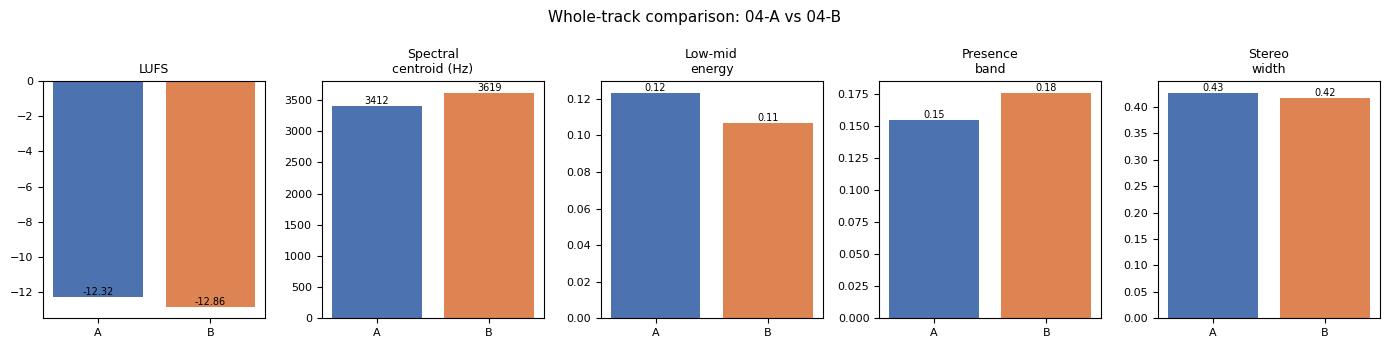

In [10]:
metrics = ["lufs", "spectral_centroid", "low_mid_energy", "presence_band", "stereo_width"]
metric_labels = ["LUFS", "Spectral\ncentroid (Hz)", "Low-mid\nenergy", "Presence\nband", "Stereo\nwidth"]

feat_a_full = extract_features(A_PATH)
feat_b_full = extract_features(B_PATH)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(metrics), figsize=(14, 3.5))
for ax, metric, label in zip(axes, metrics, metric_labels):
    values = [feat_a_full[metric], feat_b_full[metric]]
    bars = ax.bar(["A", "B"], values, color=["#4C72B0", "#DD8452"])
    ax.set_title(label, fontsize=9)
    ax.tick_params(labelsize=8)
    for bar, value in zip(bars, values):
        ax.annotate(f"{value:.2f}" if abs(value) < 100 else f"{value:.0f}",
                    (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha="center", va="bottom", fontsize=7)
fig.suptitle("Whole-track comparison: 04-A vs 04-B", fontsize=11)
fig.tight_layout()
plt.show()


### 12.2 Segment-level deltas by lyric line

Same three lines used in Section 7, plotted as deltas (B minus A) so the
sign flip across lines is visible at a glance: only `opening_vocal` pushes
positive on both metrics.


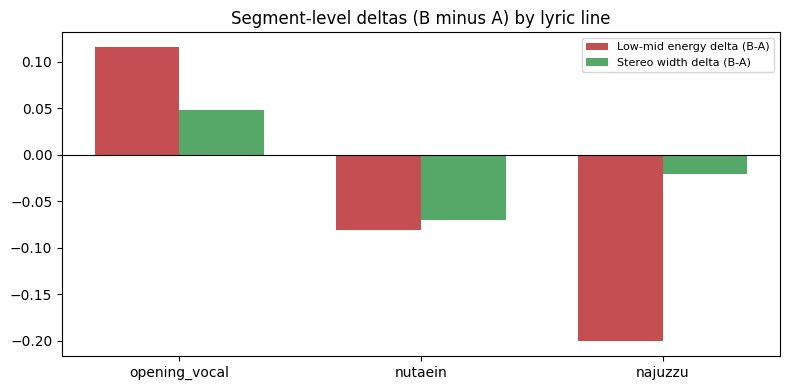

In [11]:
segment_pairs = {
    "opening_vocal": ("segments/A_opening_vocal.mp3", "segments/B_opening_vocal.mp3"),
    "nutaein":       ("segments/A_nutaein.mp3",       "segments/B_nutaein.mp3"),
    "najuzzu":       ("segments/A_najuzzu.mp3",       "segments/B_najuzzu.mp3"),
}

low_mid_deltas, width_deltas, seg_labels = [], [], []
for label, (path_a, path_b) in segment_pairs.items():
    feat_a = extract_features(path_a)
    feat_b = extract_features(path_b)
    low_mid_deltas.append(feat_b["low_mid_energy"] - feat_a["low_mid_energy"])
    width_deltas.append(feat_b["stereo_width"] - feat_a["stereo_width"])
    seg_labels.append(label)

x_pos = np.arange(len(seg_labels))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x_pos - bar_width / 2, low_mid_deltas, bar_width,
       label="Low-mid energy delta (B-A)", color="#C44E52")
ax.bar(x_pos + bar_width / 2, width_deltas, bar_width,
       label="Stereo width delta (B-A)", color="#55A868")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(seg_labels)
ax.set_title("Segment-level deltas (B minus A) by lyric line")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


### 12.3 Onset zoom — attack vs sustain

The narrowest view from Section 8: within the same sung phrase, comparing
the first 2 seconds (attack) against the following ~3 seconds (sustain).
The gap should visibly collapse from left pair to right pair on both panels.


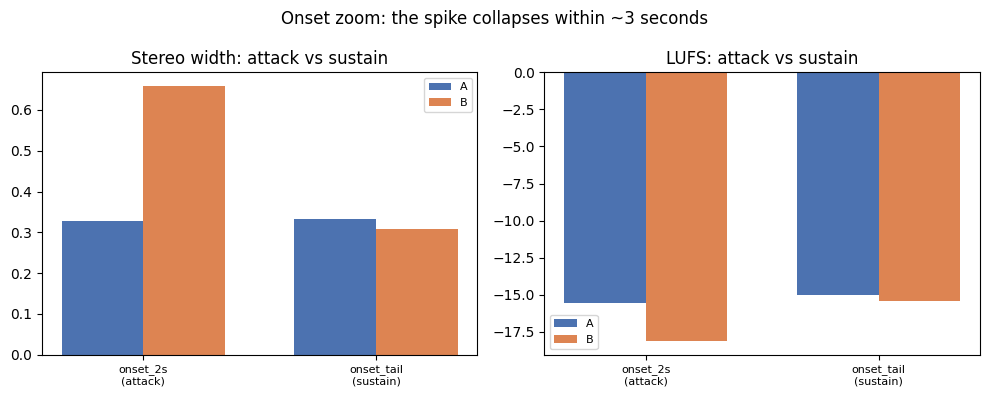

In [12]:
onset_pairs = {
    "onset_2s\n(attack)":    ("segments/onset_narrow/A_onset_2s.mp3",   "segments/onset_narrow/B_onset_2s.mp3"),
    "onset_tail\n(sustain)": ("segments/onset_narrow/A_onset_tail.mp3", "segments/onset_narrow/B_onset_tail.mp3"),
}

onset_labels, width_a_vals, width_b_vals, lufs_a_vals, lufs_b_vals = [], [], [], [], []
for label, (path_a, path_b) in onset_pairs.items():
    feat_a = extract_features(path_a)
    feat_b = extract_features(path_b)
    onset_labels.append(label)
    width_a_vals.append(feat_a["stereo_width"]); width_b_vals.append(feat_b["stereo_width"])
    lufs_a_vals.append(feat_a["lufs"]); lufs_b_vals.append(feat_b["lufs"])

x_pos = np.arange(len(onset_labels))
bar_width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(x_pos - bar_width / 2, width_a_vals, bar_width, label="A", color="#4C72B0")
axes[0].bar(x_pos + bar_width / 2, width_b_vals, bar_width, label="B", color="#DD8452")
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(onset_labels, fontsize=8)
axes[0].set_title("Stereo width: attack vs sustain")
axes[0].legend(fontsize=8)

axes[1].bar(x_pos - bar_width / 2, lufs_a_vals, bar_width, label="A", color="#4C72B0")
axes[1].bar(x_pos + bar_width / 2, lufs_b_vals, bar_width, label="B", color="#DD8452")
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(onset_labels, fontsize=8)
axes[1].set_title("LUFS: attack vs sustain")
axes[1].legend(fontsize=8)

fig.suptitle("Onset zoom: the spike collapses within ~3 seconds")
fig.tight_layout()
plt.show()


## 13. Open questions for a future session

- Does the same onset-spike pattern repeat at the second and third vocal entrances after instrumental breaks (post-Bridge, post-instrumental-break in Verse 3), or was this specific to the very first entrance?
- Would isolating the vocal stem (`--stems` mode / `extract_vocal_stem_features`) show the low-mid spike living in the vocal signal itself, or purely in the orchestral layer underneath it — this would clarify whether it's a "vocal problem" or an "arrangement timing problem."
- Could a Gemini listening pass (per `LABS_README.md`'s guidance on when to bring in multimodal listening) independently confirm the swell timing described in the B transcript, since the transcript itself is a machine-generated approximation and not a verified ground truth?